# 07 — Model Training

**Goal:** Train all three candidate models — logistic regression, decision tree, random forest —
across every leave-one-cycle-out fold (from notebook 06), collecting out-of-fold predictions
for evaluation in notebook 08. Also fits each model on the *full* dataset (all cycles) for
saving to `models/` and for the decision tree visualization below.

Uses `sklearn.tree.plot_tree` for the decision tree visualization — sklearn's own plotting,
actively maintained (the older `scikit-plot` package is unmaintained and breaks on current
scipy/numpy, so it's avoided here).

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pickle

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier

PREPROCESSED_DIR = Path("../data/preprocessed")
MODELS_DIR = Path("../results/models")
FIGURES_DIR = Path("../results/figures")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(PREPROCESSED_DIR / "labeled_dataset.csv")
FEATURE_COLS = ["temperature_C", "humidity_pct", "soil_moisture_pct", "moisture_trend", "light_lux", "hour_of_day"]
LABEL_COL = "urgency_class"
CLASS_ORDER = ["Urgent", "Soon", "Not_Urgent"]

with open(PREPROCESSED_DIR / "loco_folds.json") as f:
    folds = json.load(f)

print(f"Indoor folds: {len(folds['indoor'])}, Outdoor folds: {len(folds['outdoor'])}")

Indoor folds: 5, Outdoor folds: 5


In [2]:
def get_fold_data(df, condition, fold, feature_cols=FEATURE_COLS, label_col=LABEL_COL):
    subset = df[df["condition"] == condition]
    train = subset[subset["cycle_id"].isin(fold["train_cycles"])]
    test = subset[subset["cycle_id"] == fold["test_cycle"]]
    X_train, y_train = train[feature_cols], train[label_col]
    X_test, y_test = test[feature_cols], test[label_col]
    return X_train, y_train, X_test, y_test

MODEL_BUILDERS = {
    "logistic_regression": lambda: LogisticRegression(max_iter=1000),
    "decision_tree": lambda: DecisionTreeClassifier(max_depth=5, random_state=42),
    "random_forest": lambda: RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42),
}

## Run leave-one-cycle-out training for every model, every condition

Collects out-of-fold predictions — for every cycle, the prediction made by a model that never saw that cycle during training.

**Note on small datasets:** with very few cycles (e.g., early pipeline testing with dummy data, or a thin real dataset), a training fold can end up containing only one class — logistic regression can't fit on a single class. Rather than crash the whole pipeline, that specific (fold, model) combination is skipped with a printed warning, and evaluation in notebook 08 works from whatever predictions were successfully collected. This shouldn't happen with a healthy real dataset spanning the full urgency range, but the pipeline should degrade gracefully rather than die if it does.

In [3]:
oof_predictions = []
skipped = []

for condition in ["indoor", "outdoor"]:
    for fold in folds[condition]:
        X_train, y_train, X_test, y_test = get_fold_data(df, condition, fold)

        for model_name, builder in MODEL_BUILDERS.items():
            if y_train.nunique() < 2:
                skipped.append((condition, model_name, fold["test_cycle"], "only 1 class in training fold"))
                continue

            model = builder()
            try:
                model.fit(X_train, y_train)
                preds = model.predict(X_test)
            except Exception as e:
                skipped.append((condition, model_name, fold["test_cycle"], str(e)))
                continue

            for true_label, pred_label in zip(y_test, preds):
                oof_predictions.append({
                    "condition": condition,
                    "model": model_name,
                    "test_cycle": fold["test_cycle"],
                    "true_label": true_label,
                    "predicted_label": pred_label,
                })

oof_df = pd.DataFrame(oof_predictions)
print(f"Collected {len(oof_df)} out-of-fold predictions")

if skipped:
    print(f"\n{len(skipped)} (fold, model) combinations were skipped:")
    for condition, model_name, test_cycle, reason in skipped:
        print(f"  [{condition}] {model_name} (test={test_cycle}): {reason}")
    print("\nThis is expected with very small/imbalanced datasets (e.g. early dummy-data testing).")
    print("Check class balance in notebook 05 once real data is in — persistent skips there")
    print("would mean a real class-imbalance problem worth addressing before trusting results.")

oof_df.head()

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refe

Collected 1980 out-of-fold predictions


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,condition,model,test_cycle,true_label,predicted_label
0,indoor,logistic_regression,indoor_cycle01,Not_Urgent,Not_Urgent
1,indoor,logistic_regression,indoor_cycle01,Not_Urgent,Not_Urgent
2,indoor,logistic_regression,indoor_cycle01,Not_Urgent,Not_Urgent
3,indoor,logistic_regression,indoor_cycle01,Not_Urgent,Not_Urgent
4,indoor,logistic_regression,indoor_cycle01,Not_Urgent,Not_Urgent


In [4]:
oof_df.to_csv(PREPROCESSED_DIR / "oof_predictions.csv", index=False)
print("Saved oof_predictions.csv for notebook 08")

Saved oof_predictions.csv for notebook 08


## Fit final models on the *full* dataset (all cycles)

Used for saving to `results/models/` and for the tree visualization below. Note: these full-data models are NOT what the evaluation numbers in notebook 08 are based on — those come from the out-of-fold predictions above, which is the honest evaluation.

In [5]:
final_models = {}
X_all, y_all = df[FEATURE_COLS], df[LABEL_COL]

for model_name, builder in MODEL_BUILDERS.items():
    model = builder()
    model.fit(X_all, y_all)
    final_models[model_name] = model
    with open(MODELS_DIR / f"{model_name}.pkl", "wb") as f:
        pickle.dump(model, f)

print("Saved all three fitted models to ../results/models/")

Saved all three fitted models to ../results/models/


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## Visualize the decision tree

This is the model slated for embedded deployment (decision tree selected regardless of which
model wins evaluation, for its trivial C-portability). Worth seeing its actual learned
structure now, using sklearn's built-in `plot_tree`.

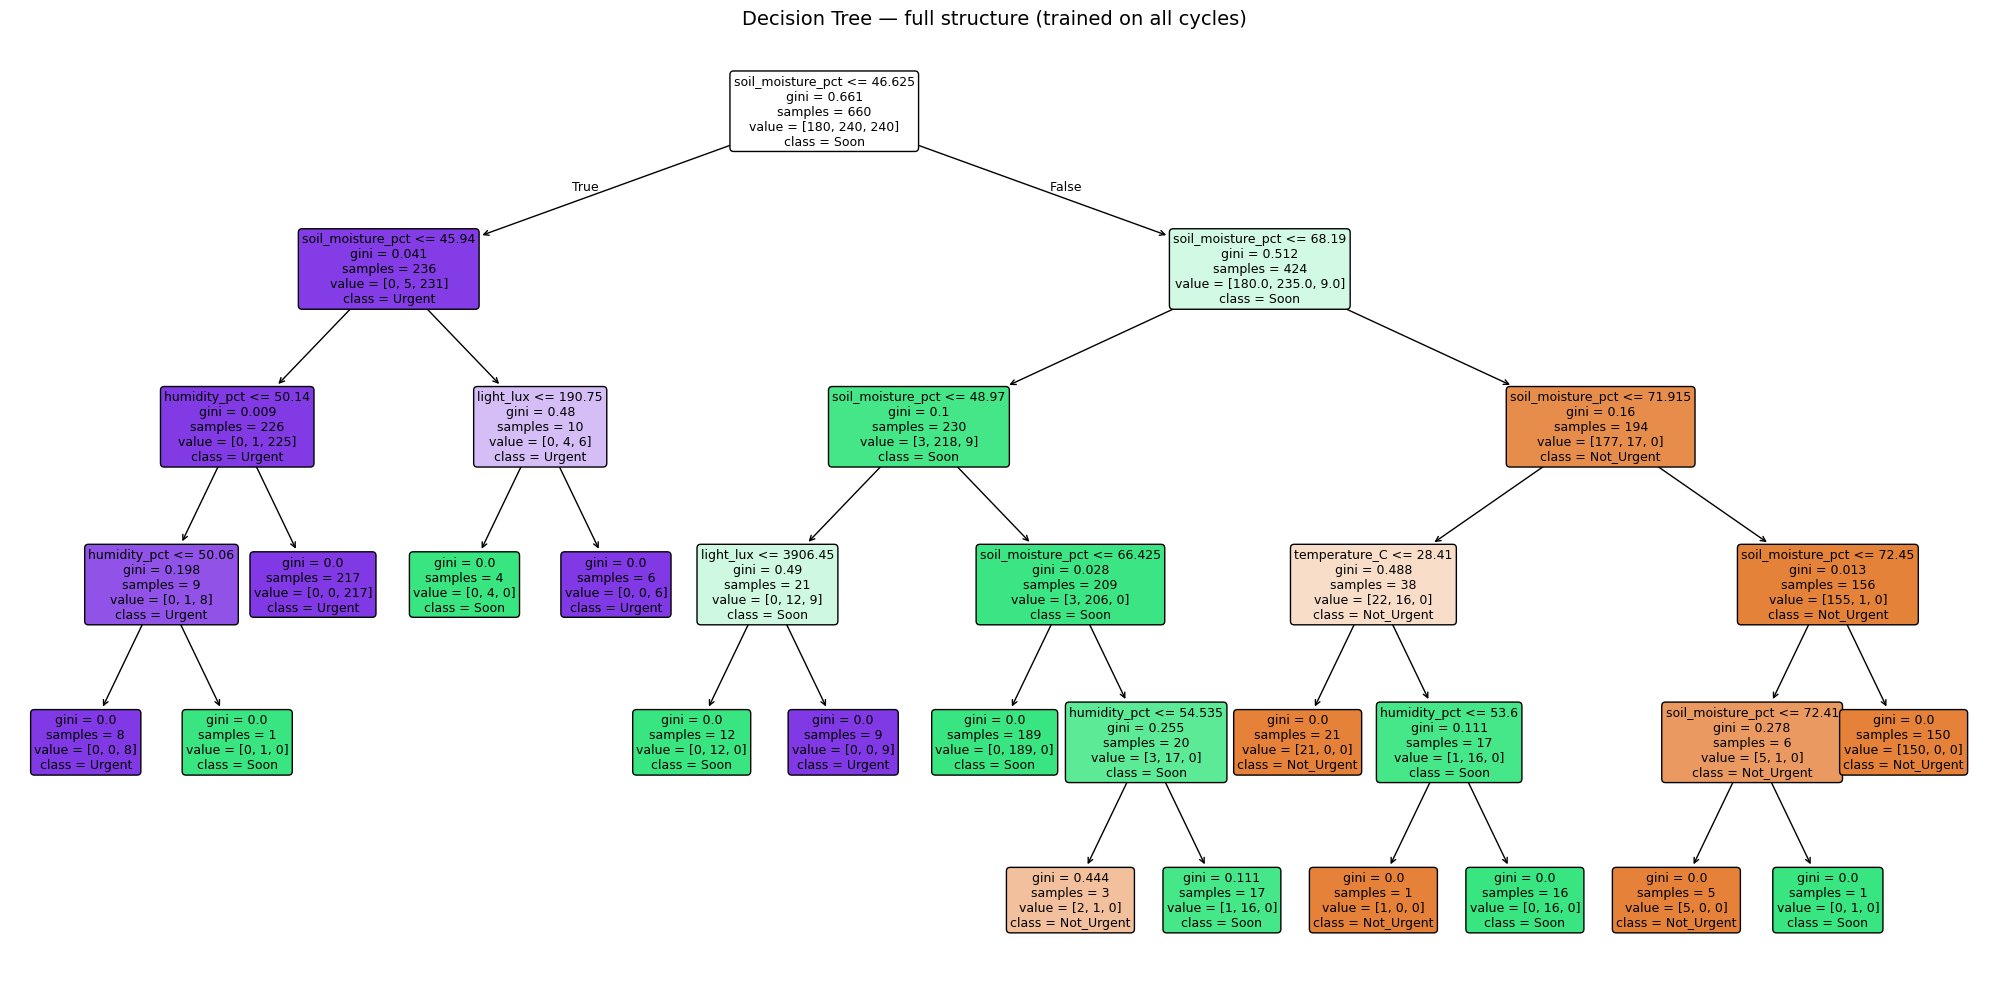

In [6]:
dt_model = final_models["decision_tree"]

fig, ax = plt.subplots(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=dt_model.classes_,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree — full structure (trained on all cycles)", fontsize=14)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_decision_tree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Feature importance — decision tree and random forest

Which of the six features is the tree actually splitting on most? Sanity check against the physical reasoning behind each feature.

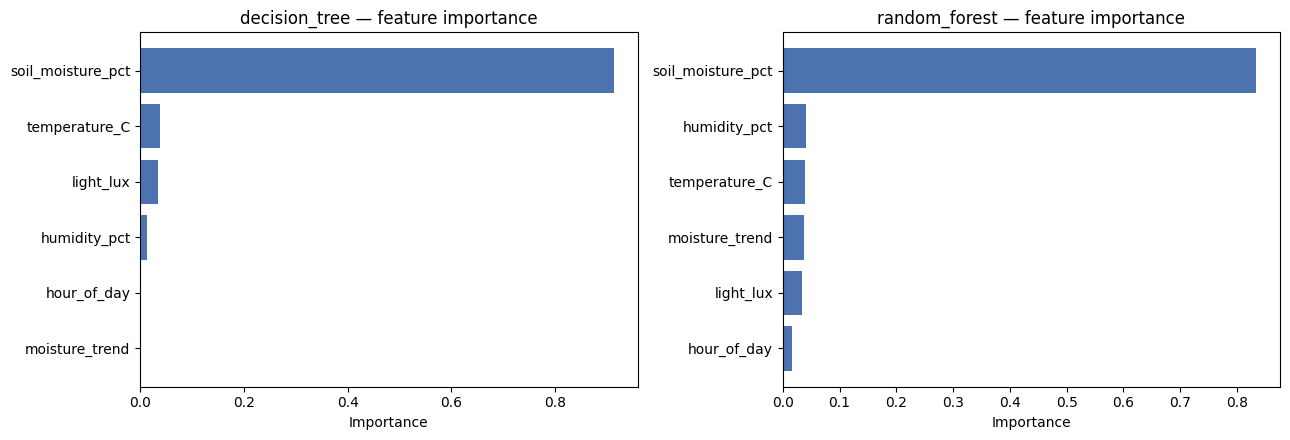

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for ax, model_name in zip(axes, ["decision_tree", "random_forest"]):
    model = final_models[model_name]
    importances = pd.Series(model.feature_importances_, index=FEATURE_COLS).sort_values()
    ax.barh(importances.index, importances.values, color="#4c72b0")
    ax.set_title(f"{model_name} — feature importance")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_feature_importance.png", dpi=120)
plt.show()

**Next step:** `08_model_evaluation.ipynb` — turn the out-of-fold predictions into confusion matrices and accuracy scores, per condition.